In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("E-commerce Customer Behavior - Sheet1.csv")
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [ ]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['customer_id', 'gender', 'age', 'city', 'membership_type',
       'total_spend', 'items_purchased', 'average_rating', 'discount_applied',
       'days_since_last_purchase', 'satisfaction_level'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
city,0
membership_type,0
total_spend,0
items_purchased,0
average_rating,0
discount_applied,0
days_since_last_purchase,0


In [ ]:
df['satisfaction_level'] = df['satisfaction_level'].fillna(df['satisfaction_level'].mode()[0])

In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
city,0
membership_type,0
total_spend,0
items_purchased,0
average_rating,0
discount_applied,0
days_since_last_purchase,0


In [ ]:
df['segment'] = 'Low Value'

df.loc[(df['total_spend'] > 1000) & (df['items_purchased'] > 10), 'segment'] = 'High Value'
df.loc[(df['total_spend'] > 500) & (df['items_purchased'] > 5), 'segment'] = 'Medium Value'

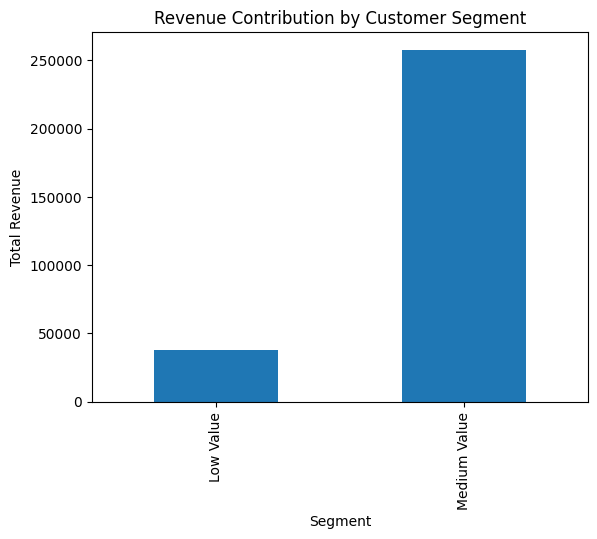

In [ ]:
df.groupby('segment')['total_spend'].sum().plot(kind='bar')
plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.show()

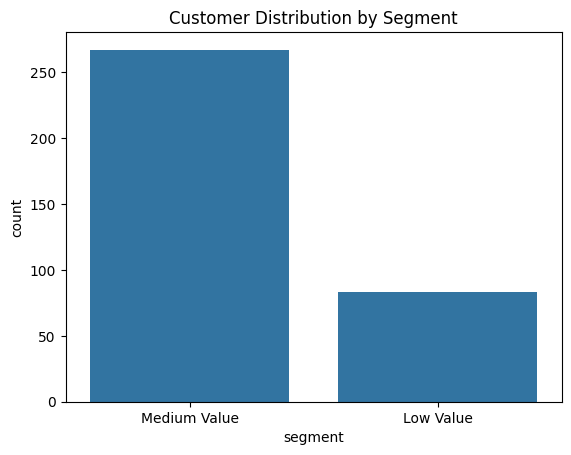

In [ ]:
sns.countplot(x='segment', data=df)
plt.title("Customer Distribution by Segment")
plt.show()

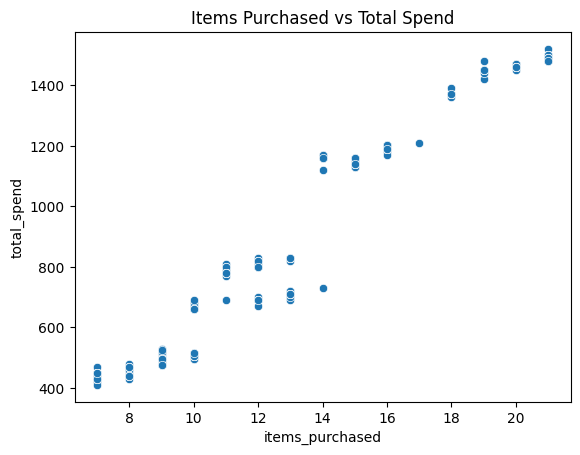

In [ ]:
sns.scatterplot(x='items_purchased', y='total_spend', data=df)
plt.title("Items Purchased vs Total Spend")
plt.show()

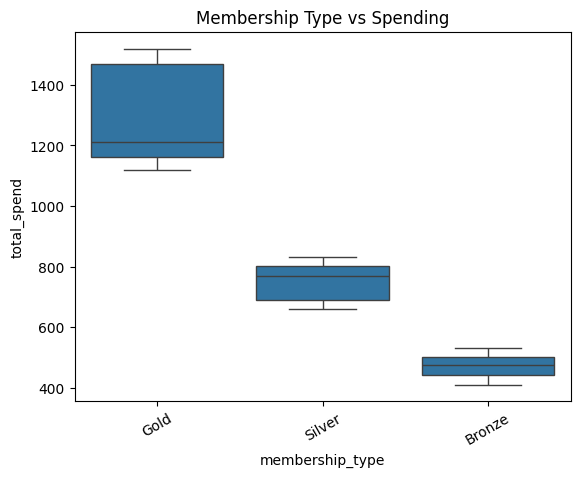

In [ ]:
sns.boxplot(x='membership_type', y='total_spend', data=df)
plt.xticks(rotation=30)
plt.title("Membership Type vs Spending")
plt.show()

In [ ]:
df['risk'] = 'Low'

df.loc[df['days_since_last_purchase'] > 30, 'risk'] = 'High'
df.loc[(df['days_since_last_purchase'] > 15) & (df['days_since_last_purchase'] <= 30), 'risk'] = 'Medium'

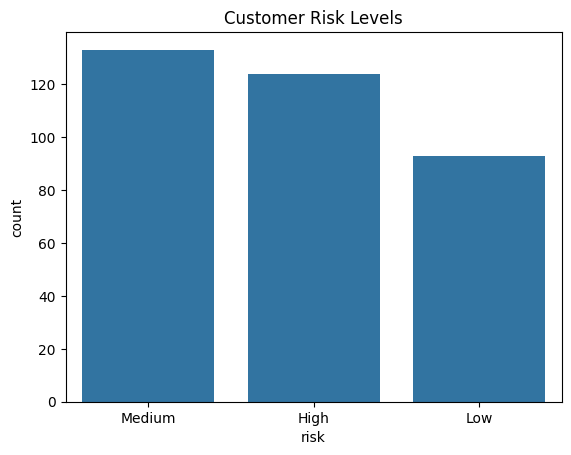

In [ ]:
sns.countplot(x='risk', data=df)
plt.title("Customer Risk Levels")
plt.show()

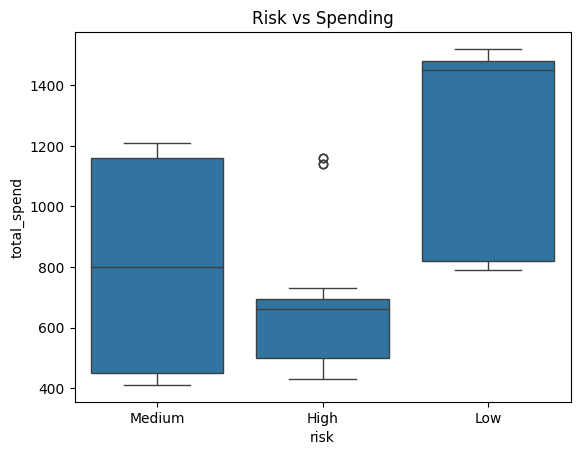

In [ ]:
sns.boxplot(x='risk', y='total_spend', data=df)
plt.title("Risk vs Spending")
plt.show()

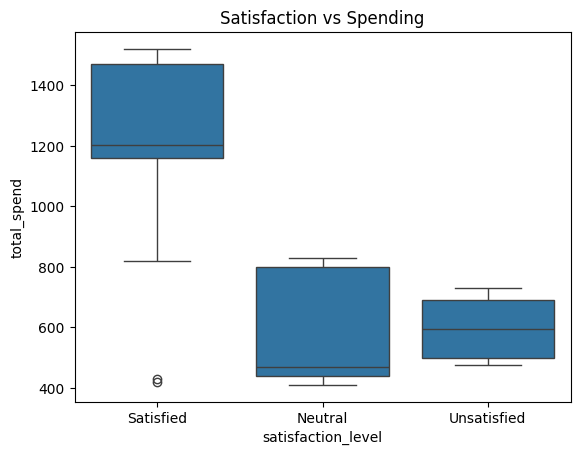

In [ ]:
sns.boxplot(x='satisfaction_level', y='total_spend', data=df)
plt.title("Satisfaction vs Spending")
plt.show()

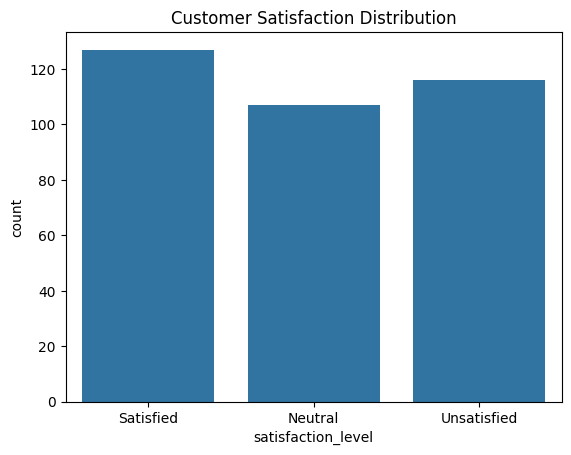

In [ ]:
sns.countplot(x='satisfaction_level', data=df)
plt.title("Customer Satisfaction Distribution")
plt.show()

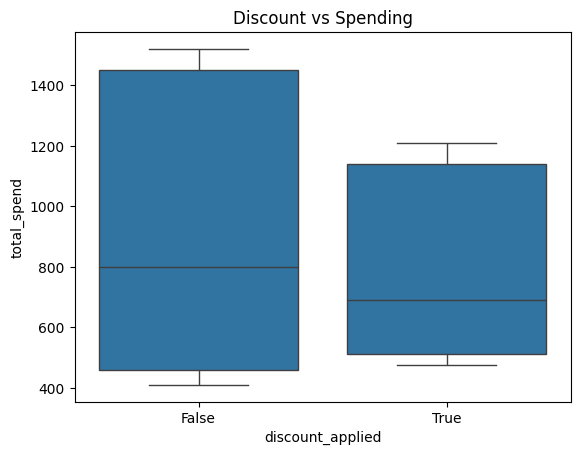

In [ ]:
sns.boxplot(x='discount_applied', y='total_spend', data=df)
plt.title("Discount vs Spending")
plt.show()

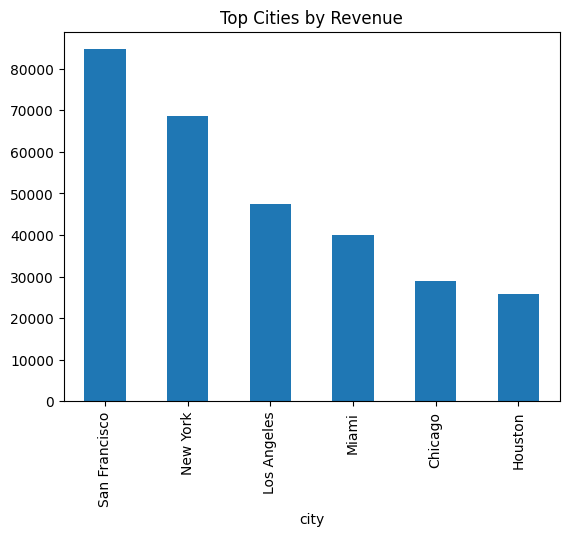

In [ ]:
df.groupby('city')['total_spend'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Cities by Revenue")
plt.show()